In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
#Step 1: time-series data(temperature)
data=np.array([30,31,29,32,33,34,35,36,34,33,32,31,30])

In [ ]:
#Step 2: prepare sequences
def create_dataset(data, time_steps=3):
  X,y=[],[]
  for I in range(len(data)-time_steps):
    X.append(data[I:(I+time_steps)])
    y.append(data[I+time_steps])
  return np.array(X),np.array(y)
X,y=create_dataset(data)

In [ ]:
#Step 3: reshape for RNN
X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
#Step 4: build RNN model
model=Sequential([
    LSTM(50,activation='tanh',input_shape=(3,1)),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Step 5: Train model
model.compile(optimizer='adam', loss='mse')
model.fit(X,y,epochs=200, verbose=0)

In [ ]:
#Step 6: predict next value
test_input=np.array([31,32,33])
test_input=test_input.reshape((1,3,1))

prediction=model.predict(test_input)
print("Predicted next day temperature:", prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Predicted next day temperature: 18.48729


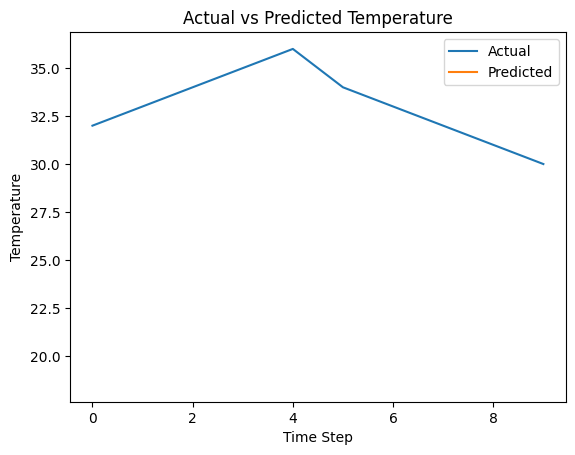

In [ ]:
import matplotlib.pyplot as plt
from sys import platform
#graph plot for this sequence(actual vs predicted)
plt.figure()
plt.plot(y, label="Actual")
plt.plot(prediction.flatten(), label="Predicted")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()
plt.show()